In [ ]:
import pandas as pd

df = pd.read_excel('mercado.xlsx')

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   edad          100 non-null    int64 
 1   estrato_nse   100 non-null    object
 2   canal_compra  100 non-null    object
 3   gasto         100 non-null    int64 
 4   arroz         100 non-null    int64 
 5   leche         100 non-null    int64 
 6   huevos        100 non-null    int64 
 7   pan           100 non-null    int64 
 8   pollo         100 non-null    int64 
 9   carne_res     100 non-null    int64 
 10  cafe          100 non-null    int64 
 11  azucar        100 non-null    int64 
 12  aceite        100 non-null    int64 
 13  galletas      100 non-null    int64 
 14  detergente    100 non-null    int64 
dtypes: int64(13), object(2)
memory usage: 11.8+ KB


In [ ]:
productos = df.drop(columns=['edad', 'estrato_nse', 'canal_compra', 'gasto'])

productos.head()

,arroz,leche,huevos,pan,pollo,carne_res,cafe,azucar,aceite,galletas,detergente
0,0,1,0,0,0,1,1,0,1,1,1
1,1,1,1,1,1,0,0,0,0,0,1
2,0,0,0,1,0,1,0,0,1,1,0
3,0,1,0,1,1,1,1,1,0,1,1
4,1,0,1,0,1,0,1,1,0,0,0


In [ ]:
pip install mlxtend

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(productos, min_support=0.2, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules.head()



/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(arroz),(huevos),0.71,0.58,0.47,0.661972,1.141331,1.0,0.0582,1.242500,0.426999,0.573171,0.195171,0.736158
1,(huevos),(arroz),0.58,0.71,0.47,0.810345,1.141331,1.0,0.0582,1.529091,0.294833,0.573171,0.346017,0.736158
2,(arroz),(pan),0.71,0.56,0.41,0.577465,1.031187,1.0,0.0124,1.041333,0.104289,0.476744,0.039693,0.654804
3,(pan),(arroz),0.56,0.71,0.41,0.732143,1.031187,1.0,0.0124,1.082667,0.068736,0.476744,0.076355,0.654804
4,(arroz),(pollo),0.71,0.50,0.38,0.535211,1.070423,1.0,0.0250,1.075758,0.226860,0.457831,0.070423,0.647606


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Afinidad
rules['affinity'] = rules['confidence'] * rules['lift']

# Score de negocio
rules['score'] = (
    0.4 * rules['support'] +
    0.3 * rules['confidence'] +
    0.3 * rules['lift']
)

rules.sort_values(by='affinity', ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,affinity,score
176,"(carne_res, cafe)",(pollo),0.28,0.50,0.21,0.750000,1.500000,1.0,0.0700,2.000000,0.462963,0.368421,0.500000,0.585000,1.125000,0.759000
80,"(pollo, huevos)",(arroz),0.28,0.71,0.24,0.857143,1.207243,1.0,0.0412,2.030000,0.238426,0.320000,0.507389,0.597586,1.034780,0.715316
98,"(detergente, huevos)",(arroz),0.27,0.71,0.23,0.851852,1.199791,1.0,0.0383,1.957500,0.228112,0.306667,0.489144,0.587898,1.022044,0.707493
89,"(huevos, azucar)",(arroz),0.33,0.71,0.28,0.848485,1.195049,1.0,0.0457,1.914000,0.243603,0.368421,0.477534,0.621426,1.013981,0.725060
96,"(arroz, detergente)",(huevos),0.30,0.58,0.23,0.766667,1.321839,1.0,0.0560,1.800000,0.347826,0.353846,0.444444,0.581609,1.013410,0.718552
168,"(detergente, pan)",(azucar),0.26,0.60,0.20,0.769231,1.282051,1.0,0.0440,1.733333,0.297297,0.303030,0.423077,0.551282,0.986193,0.695385
57,"(leche, huevos)",(arroz),0.30,0.71,0.25,0.833333,1.173709,1.0,0.0370,1.740000,0.211429,0.328947,0.425287,0.592723,0.978091,0.702113
1,(huevos),(arroz),0.58,0.71,0.47,0.810345,1.141331,1.0,0.0582,1.529091,0.294833,0.573171,0.346017,0.736158,0.924871,0.773503
85,"(huevos, cafe)",(arroz),0.31,0.71,0.25,0.806452,1.135847,1.0,0.0299,1.498333,0.173333,0.324675,0.332592,0.579282,0.916006,0.682690
75,"(pan, huevos)",(arroz),0.31,0.71,0.25,0.806452,1.135847,1.0,0.0299,1.498333,0.173333,0.324675,0.332592,0.579282,0.916006,0.682690


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

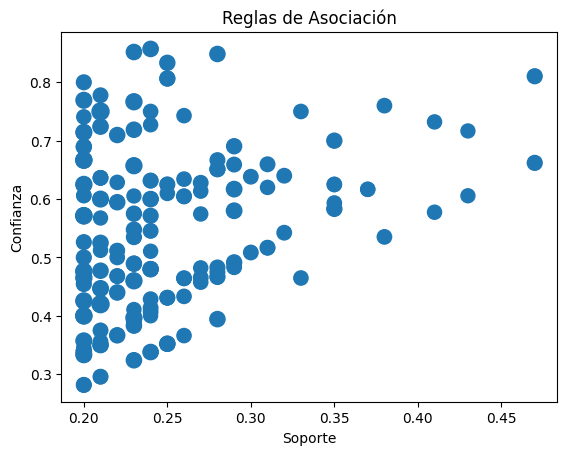

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    rules['support'],
    rules['confidence'],
    s=rules['lift']*100
)

plt.xlabel('Soporte')
plt.ylabel('Confianza')
plt.title('Reglas de Asociación')

plt.show()

In [ ]:
top = rules.sort_values(by='affinity', ascending=False).head(10)

top[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'affinity']]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift,affinity
176,"(carne_res, cafe)",(pollo),0.21,0.750000,1.500000,1.125000
80,"(pollo, huevos)",(arroz),0.24,0.857143,1.207243,1.034780
98,"(detergente, huevos)",(arroz),0.23,0.851852,1.199791,1.022044
89,"(huevos, azucar)",(arroz),0.28,0.848485,1.195049,1.013981
96,"(arroz, detergente)",(huevos),0.23,0.766667,1.321839,1.013410
168,"(detergente, pan)",(azucar),0.20,0.769231,1.282051,0.986193
57,"(leche, huevos)",(arroz),0.25,0.833333,1.173709,0.978091
1,(huevos),(arroz),0.47,0.810345,1.141331,0.924871
85,"(huevos, cafe)",(arroz),0.25,0.806452,1.135847,0.916006
75,"(pan, huevos)",(arroz),0.25,0.806452,1.135847,0.916006


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

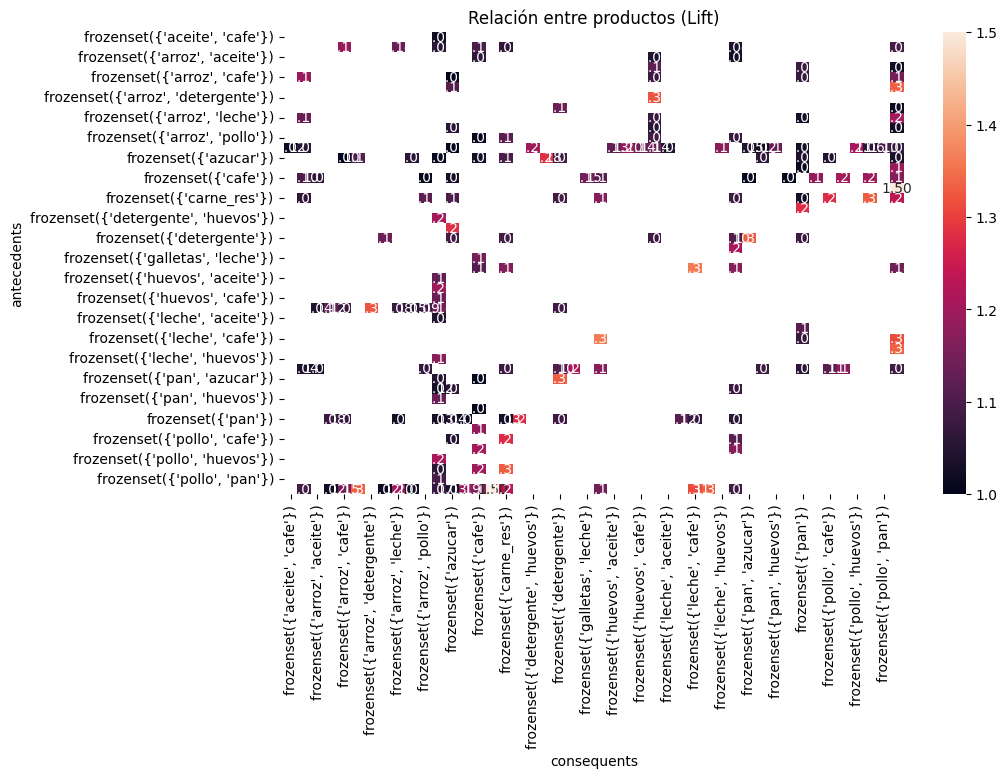

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import seaborn as sns

rules['antecedents'] = rules['antecedents'].astype(str)
rules['consequents'] = rules['consequents'].astype(str)

pivot = rules.pivot_table(
    index='antecedents',
    columns='consequents',
    values='lift'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".2f")

plt.title('Relación entre productos (Lift)')
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

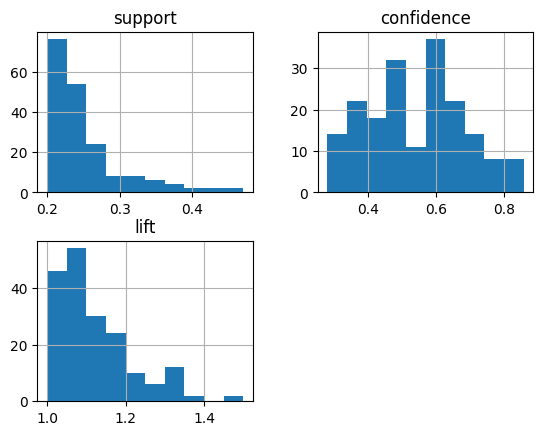

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
rules[['support', 'confidence', 'lift']].hist()
plt.show()

In [ ]:
for canal in df['canal_compra'].unique():

    subset = df[df['canal_compra'] == canal]
    productos_subset = subset.drop(columns=['edad', 'estrato_nse', 'canal_compra', 'gasto'])

    freq = apriori(productos_subset, min_support=0.2, use_colnames=True)
    rules_subset = association_rules(freq, metric="lift", min_threshold=1)

    print(f"\nCanal: {canal}")
    print(rules_subset.sort_values(by='lift', ascending=False).head(5))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Canal: Tienda
               antecedents            consequents  antecedent support  \
330             (galletas)  (leche, aceite, cafe)            0.400000   
323  (leche, aceite, cafe)             (galletas)            0.228571   
325       (galletas, cafe)        (leche, aceite)            0.342857   
328        (leche, aceite)       (galletas, cafe)            0.285714   
329         (aceite, cafe)      (galletas, leche)            0.314286   

     consequent support  support  confidence      lift  representativity  \
330            0.228571      0.2    0.500000  2.187500               1.0   
323            0.400000      0.2    0.875000  2.187500               1.0   
325            0.285714      0.2    0.583333  2.041667               1.0   
328            0.342857      0.2    0.700000  2.041667               1.0   
329            0.314286      0.2    0.636364  2.024793               1.0   

     leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
330  0.108571

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Frecuencia de productos
frecuencia = productos.sum().sort_values(ascending=False)

frecuencia

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,0
arroz,71
azucar,60
cafe,60
leche,59
huevos,58
pan,56
pollo,50
carne_res,47
aceite,44
detergente,43


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


ECLAT

In [ ]:
import pandas as pd

df = pd.read_excel('mercado.xlsx')

productos = df.drop(columns=['edad', 'estrato_nse', 'canal_compra', 'gasto'])

# Convertir a transacciones
transactions = []

for _, row in productos.iterrows():
    trans = list(productos.columns[row == 1])
    transactions.append(trans)

transactions[:5]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[['leche', 'carne_res', 'cafe', 'aceite', 'galletas', 'detergente'],
 ['arroz', 'leche', 'huevos', 'pan', 'pollo', 'detergente'],
 ['pan', 'carne_res', 'aceite', 'galletas'],
 ['leche',
  'pan',
  'pollo',
  'carne_res',
  'cafe',
  'azucar',
  'galletas',
  'detergente'],
 ['arroz', 'huevos', 'pollo', 'cafe', 'azucar']]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Crear TID list (formato vertical)
tid_lists = {}

for i, trans in enumerate(transactions):
    for item in trans:
        if item not in tid_lists:
            tid_lists[item] = set()
        tid_lists[item].add(i)

tid_lists

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

{'leche': {0,
  1,
  3,
  7,
  9,
  10,
  13,
  16,
  19,
  20,
  21,
  22,
  23,
  24,
  30,
  35,
  36,
  37,
  39,
  40,
  41,
  44,
  47,
  48,
  49,
  50,
  54,
  56,
  59,
  61,
  62,
  63,
  64,
  65,
  66,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  80,
  81,
  82,
  83,
  85,
  86,
  87,
  88,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  99},
 'carne_res': {0,
  2,
  3,
  6,
  10,
  12,
  13,
  14,
  18,
  19,
  20,
  26,
  33,
  35,
  36,
  39,
  40,
  41,
  45,
  49,
  51,
  52,
  54,
  56,
  58,
  59,
  64,
  67,
  69,
  72,
  73,
  75,
  78,
  79,
  80,
  83,
  84,
  85,
  86,
  87,
  88,
  90,
  92,
  93,
  95,
  97,
  99},
 'cafe': {0,
  3,
  4,
  7,
  8,
  10,
  12,
  13,
  14,
  15,
  18,
  20,
  21,
  22,
  23,
  24,
  25,
  27,
  28,
  33,
  34,
  35,
  37,
  38,
  39,
  42,
  43,
  45,
  46,
  47,
  48,
  49,
  50,
  52,
  53,
  55,
  56,
  57,
  61,
  64,
  65,
  66,
  67,
  68,
  70,
  75,
  76,
  77,
  80,
  83,
  84,
  85,
  86,
  88,
  89,
  90,
  91,
  95

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from itertools import combinations

min_support = 0.2
n = len(transactions)

frequent_itemsets = []

items = list(tid_lists.keys())

for i in range(1, 4):  # tamaño de combinaciones
    for combo in combinations(items, i):

        # Intersección de TIDs
        tids = tid_lists[combo[0]]

        for item in combo[1:]:
            tids = tids.intersection(tid_lists[item])

        support = len(tids) / n

        if support >= min_support:
            frequent_itemsets.append({
                'itemset': combo,
                'support': support
            })

import pandas as pd
freq_df = pd.DataFrame(frequent_itemsets)

freq_df

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,itemset,support
0,"(leche,)",0.59
1,"(carne_res,)",0.47
2,"(cafe,)",0.60
3,"(aceite,)",0.44
4,"(galletas,)",0.42
...,...,...
88,"(arroz, huevos, pollo)",0.24
89,"(arroz, huevos, azucar)",0.28
90,"(arroz, pan, pollo)",0.21
91,"(arroz, pan, azucar)",0.26


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
rules = []

for _, row in freq_df.iterrows():
    items = list(row['itemset'])

    if len(items) >= 2:
        for i in range(len(items)):

            antecedent = (items[i],)
            consequent = tuple([x for x in items if x != items[i]])

            sup_itemset = row['support']

            sup_ante = freq_df[
                freq_df['itemset'] == antecedent
            ]['support'].values

            if len(sup_ante) > 0:
                confidence = sup_itemset / sup_ante[0]

                rules.append({
                    'antecedent': antecedent,
                    'consequent': consequent,
                    'support': sup_itemset,
                    'confidence': confidence
                })

rules_df = pd.DataFrame(rules)
rules_df

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedent,consequent,support,confidence
0,"(leche,)","(carne_res,)",0.30,0.508475
1,"(carne_res,)","(leche,)",0.30,0.638298
2,"(leche,)","(cafe,)",0.35,0.593220
3,"(cafe,)","(leche,)",0.35,0.583333
4,"(leche,)","(aceite,)",0.27,0.457627
...,...,...,...,...
189,"(pan,)","(arroz, azucar)",0.26,0.464286
190,"(azucar,)","(arroz, pan)",0.26,0.433333
191,"(arroz,)","(pollo, azucar)",0.22,0.309859
192,"(pollo,)","(arroz, azucar)",0.22,0.440000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Lift
def get_support(item):
    val = freq_df[freq_df['itemset'] == item]['support']
    return val.values[0] if len(val) > 0 else 0

lifts = []

for _, row in rules_df.iterrows():
    sup_b = get_support(row['consequent'])

    if sup_b > 0:
        lift = row['confidence'] / sup_b
    else:
        lift = 0

    lifts.append(lift)

rules_df['lift'] = lifts

# Afinidad
rules_df['affinity'] = rules_df['confidence'] * rules_df['lift']

# Score negocio
rules_df['score'] = (
    0.4 * rules_df['support'] +
    0.3 * rules_df['confidence'] +
    0.3 * rules_df['lift']
)

rules_df.sort_values(by='affinity', ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedent,consequent,support,confidence,lift,affinity,score
85,"(huevos,)","(arroz,)",0.47,0.810345,1.141331,0.924871,0.773503
51,"(pollo,)","(cafe,)",0.35,0.700000,1.166667,0.816667,0.700000
89,"(pollo,)","(arroz,)",0.38,0.760000,1.070423,0.813521,0.701127
7,"(galletas,)","(leche,)",0.29,0.690476,1.170299,0.808063,0.674232
54,"(aceite,)","(arroz,)",0.33,0.750000,1.056338,0.792254,0.673901
34,"(carne_res,)","(pollo,)",0.29,0.617021,1.234043,0.761431,0.671319
84,"(arroz,)","(huevos,)",0.47,0.661972,1.141331,0.755529,0.728991
87,"(pan,)","(arroz,)",0.41,0.732143,1.031187,0.754976,0.692999
41,"(galletas,)","(cafe,)",0.28,0.666667,1.111111,0.740741,0.645333
36,"(carne_res,)","(azucar,)",0.31,0.659574,1.099291,0.725064,0.651660


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

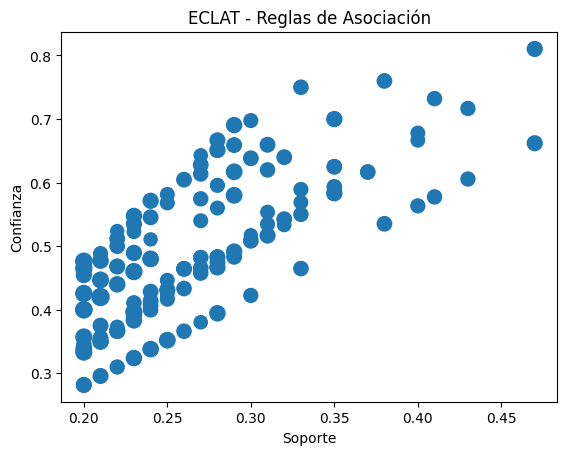

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    rules_df['support'],
    rules_df['confidence'],
    s=rules_df['lift'] * 100
)

plt.xlabel('Soporte')
plt.ylabel('Confianza')
plt.title('ECLAT - Reglas de Asociación')

plt.show()

In [ ]:
top = rules_df.sort_values(by='affinity', ascending=False).head(10)

top[['antecedent', 'consequent', 'support', 'confidence', 'lift', 'affinity']]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedent,consequent,support,confidence,lift,affinity
85,"(huevos,)","(arroz,)",0.47,0.810345,1.141331,0.924871
51,"(pollo,)","(cafe,)",0.35,0.700000,1.166667,0.816667
89,"(pollo,)","(arroz,)",0.38,0.760000,1.070423,0.813521
7,"(galletas,)","(leche,)",0.29,0.690476,1.170299,0.808063
54,"(aceite,)","(arroz,)",0.33,0.750000,1.056338,0.792254
34,"(carne_res,)","(pollo,)",0.29,0.617021,1.234043,0.761431
84,"(arroz,)","(huevos,)",0.47,0.661972,1.141331,0.755529
87,"(pan,)","(arroz,)",0.41,0.732143,1.031187,0.754976
41,"(galletas,)","(cafe,)",0.28,0.666667,1.111111,0.740741
36,"(carne_res,)","(azucar,)",0.31,0.659574,1.099291,0.725064


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

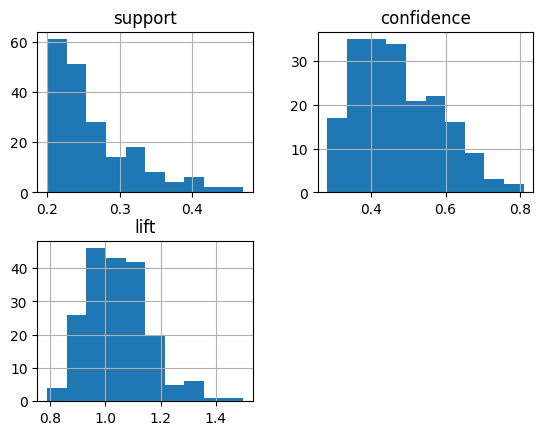

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
rules_df[['support', 'confidence', 'lift']].hist()
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

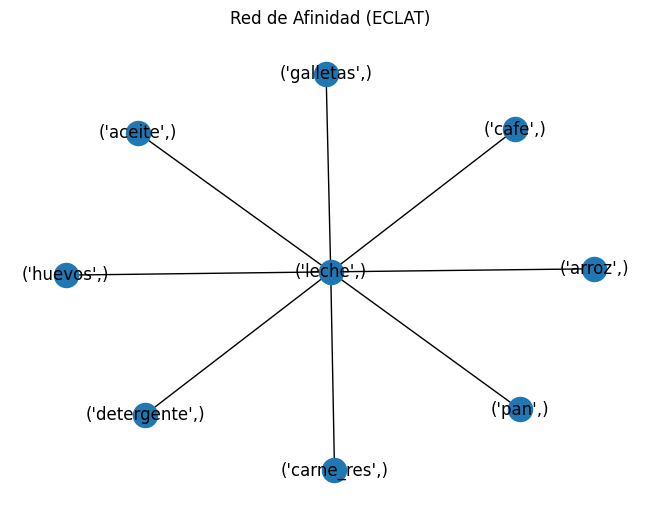

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import networkx as nx

G = nx.from_pandas_edgelist(
    rules_df.head(15),
    source='antecedent',
    target='consequent',
    edge_attr='lift'
)

plt.figure()
nx.draw(G, with_labels=True)
plt.title("Red de Afinidad (ECLAT)")
plt.show()

In [ ]:
afinidad_producto = rules_df.groupby('antecedent')['affinity'].mean().sort_values(ascending=False)

afinidad_producto

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,affinity
antecedent,
"(detergente,)",0.626770
"(galletas,)",0.605459
"(aceite,)",0.577040
"(pollo,)",0.576243
"(carne_res,)",0.570918
"(huevos,)",0.487903
"(pan,)",0.480811
"(leche,)",0.457903
"(cafe,)",0.457193


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## SEGMENTO

In [ ]:
df['grupo_edad'] = pd.cut(
    df['edad'],
    bins=[0, 25, 35, 50, 100],
    labels=['Joven', 'Adulto joven', 'Adulto', 'Senior']
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from itertools import combinations
import pandas as pd

def eclat_segmento(data, min_support=0.2, max_len=3):

    productos = data.drop(columns=['edad', 'estrato_nse', 'canal_compra', 'gasto', 'grupo_edad'], errors='ignore')

    # Transacciones
    transactions = []
    for _, row in productos.iterrows():
        trans = list(productos.columns[row == 1])
        transactions.append(trans)

    # TID list
    tid_lists = {}
    for i, trans in enumerate(transactions):
        for item in trans:
            tid_lists.setdefault(item, set()).add(i)

    n = len(transactions)
    results = []

    items = list(tid_lists.keys())

    for i in range(1, max_len+1):
        for combo in combinations(items, i):

            tids = tid_lists[combo[0]]
            for item in combo[1:]:
                tids = tids.intersection(tid_lists[item])

            support = len(tids) / n

            if support >= min_support:
                results.append({'itemset': combo, 'support': support})

    freq_df = pd.DataFrame(results)

    return freq_df

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
resultados_estrato = {}

for estrato in df['estrato_nse'].unique():

    subset = df[df['estrato_nse'] == estrato]

    freq = eclat_segmento(subset, min_support=0.2)

    resultados_estrato[estrato] = freq

    print(f"\nEstrato: {estrato}")
    print(freq.sort_values(by='support', ascending=False).head(5))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Estrato: E1
           itemset   support
0         (leche,)  0.809524
6         (arroz,)  0.761905
16  (leche, arroz)  0.571429
10       (huevos,)  0.571429
8         (pollo,)  0.523810

Estrato: E5
     itemset   support
0   (arroz,)  0.764706
1   (leche,)  0.705882
9    (cafe,)  0.647059
2  (huevos,)  0.588235
3     (pan,)  0.588235

Estrato: E3
       itemset   support
8      (cafe,)  0.608696
2    (aceite,)  0.521739
4     (arroz,)  0.521739
0       (pan,)  0.521739
3  (galletas,)  0.478261

Estrato: E4
         itemset  support
5      (azucar,)     0.84
8       (arroz,)     0.76
7  (detergente,)     0.68
1         (pan,)     0.68
9      (huevos,)     0.64

Estrato: E2
            itemset   support
4         (azucar,)  1.000000
0          (arroz,)  0.785714
14  (arroz, azucar)  0.785714
3           (cafe,)  0.714286
29   (cafe, azucar)  0.714286


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
resultados_edad = {}

for grupo in df['grupo_edad'].dropna().unique():

    subset = df[df['grupo_edad'] == grupo]

    freq = eclat_segmento(subset, min_support=0.2)

    resultados_edad[grupo] = freq

    print(f"\nGrupo edad: {grupo}")
    print(freq.sort_values(by='support', ascending=False).head(5))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Grupo edad: Adulto
      itemset   support
0    (leche,)  0.678571
10  (azucar,)  0.678571
6      (pan,)  0.642857
8   (huevos,)  0.571429
7    (arroz,)  0.535714

Grupo edad: Adulto joven
            itemset   support
0          (arroz,)  0.791667
2         (huevos,)  0.791667
12  (arroz, huevos)  0.708333
7           (cafe,)  0.625000
5     (detergente,)  0.625000

Grupo edad: Joven
    itemset   support
0  (arroz,)  0.615385
2  (pollo,)  0.615385
8   (cafe,)  0.615385
4  (leche,)  0.538462
1    (pan,)  0.538462

Grupo edad: Senior
     itemset   support
0   (arroz,)  0.828571
3    (cafe,)  0.685714
4  (azucar,)  0.600000
5  (aceite,)  0.542857
7   (leche,)  0.542857


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
for estrato, data in resultados_estrato.items():

    print(f"\nEstrato {estrato}")

    top = data[data['itemset'].apply(len) == 1] \
        .sort_values(by='support', ascending=False)

    print(top.head(3))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Estrato E1
      itemset   support
0    (leche,)  0.809524
6    (arroz,)  0.761905
10  (huevos,)  0.571429

Estrato E5
    itemset   support
0  (arroz,)  0.764706
1  (leche,)  0.705882
9   (cafe,)  0.647059

Estrato E3
     itemset   support
8    (cafe,)  0.608696
2  (aceite,)  0.521739
0     (pan,)  0.521739

Estrato E4
     itemset  support
5  (azucar,)     0.84
8   (arroz,)     0.76
1     (pan,)     0.68

Estrato E2
     itemset   support
4  (azucar,)  1.000000
0   (arroz,)  0.785714
3    (cafe,)  0.714286


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

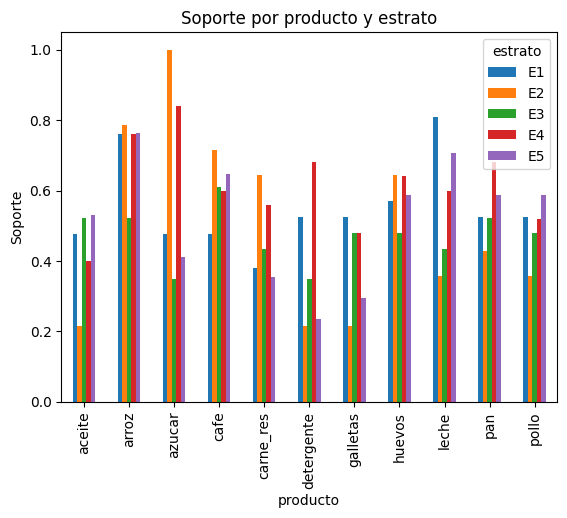

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt

productos_lista = []

for estrato, data in resultados_estrato.items():

    singles = data[data['itemset'].apply(len) == 1]

    for _, row in singles.iterrows():
        productos_lista.append({
            'estrato': estrato,
            'producto': row['itemset'][0],
            'support': row['support']
        })

plot_df = pd.DataFrame(productos_lista)

pivot = plot_df.pivot(index='producto', columns='estrato', values='support')

pivot.plot(kind='bar')

plt.title("Soporte por producto y estrato")
plt.ylabel("Soporte")
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

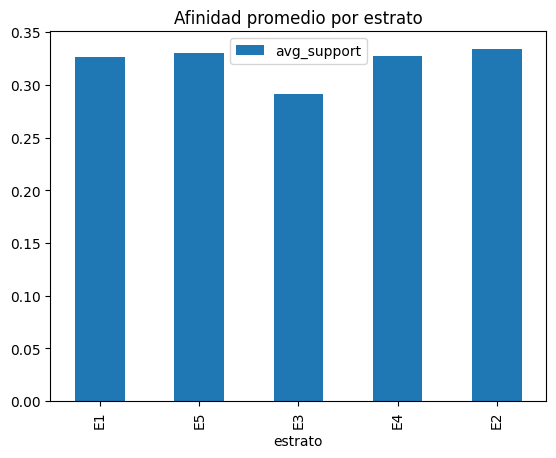

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
afinidad_segmento = []

for estrato, data in resultados_estrato.items():

    avg_support = data['support'].mean()

    afinidad_segmento.append({
        'estrato': estrato,
        'avg_support': avg_support
    })

afinidad_df = pd.DataFrame(afinidad_segmento)

afinidad_df.plot(x='estrato', y='avg_support', kind='bar')

plt.title("Afinidad promedio por estrato")
plt.show()